In [449]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import matplotlib.patches as mpatches

In [450]:
CSF_AD = pd.read_csv('data/CSF_AD.csv')
dx_df = pd.read_csv('data/DXSUM_17Feb2026.csv')

In [451]:
# Check that no rows have been duplicated from merges in the previous script
print(CSF_AD.groupby(['RID','VISCODE']).size().sort_values(ascending=False).head())

RID   VISCODE
3     bl         1
4399  v11        1
      v03        1
      init       1
4396  v21        1
dtype: int64


In [452]:
def pretty_label(var_name):
    """
    Converts snake_case variable names into publication-ready labels.
    """

    # Remove common prefixes
    prefixes = ["adas_", "cdr_", "mmse_"]
    for p in prefixes:
        if var_name.startswith(p):
            var_name = var_name[len(p):]

    # Replace underscores with spaces
    var_name = var_name.replace("_", " ")

    # Capitalize words
    var_name = var_name.title()

    return f"{var_name} Score (ADAS-Cog)" 


In [453]:
from matplotlib.ticker import MaxNLocator

def quadratic_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors with 95% CIs,
    and saves observed vs fitted trajectory plots.
    """

    formula = f"""
    {variable} ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + CM
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_years:PT_AB_std
    + time_years:age_c
    + time_years:PTGENDER
    + time_years:edu_c
    + time_sq:CARRIER
    + time_sq:edu_c
    + time_sq:age_c
    + time_sq:PT_AB_std
    + time_years:Sleep
    + time_years:UTI
    + time_years:CM
    + time_sq:Sleep
    + time_sq:UTI
    + time_sq:CM

    
    
    """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)

    # ── Confidence intervals ───────────────────────────────────────────────
    ci = model.conf_int()
    ci.columns = ["CI_lower", "CI_upper"]

    results = pd.DataFrame({
        "coef":     model.params,
        "CI_lower": ci["CI_lower"],
        "CI_upper": ci["CI_upper"],
        "pval":     model.pvalues
    })

    # ── Marginal and Conditional R² ───────────────────────────────────────
    var_fixed  = float(np.var(model.fittedvalues - model.resid))
    var_random = float(model.cov_re.iloc[0, 0])   # random intercept variance
    var_resid  = float(model.scale)                # residual variance

    r2_marginal    = var_fixed / (var_fixed + var_random + var_resid)
    r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

    # ── Print significant results ─────────────────────────────────────────
    sig_results = results[results["pval"] < 0.1].copy()
    sig_results["CI"] = (
        sig_results["CI_lower"].round(3).astype(str)
        + ", "
        + sig_results["CI_upper"].round(3).astype(str)
    )

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results[["coef", "CI_lower", "CI_upper", "pval"]].round(4))

    print(f"\nModel fit statistics:")
    print(f"  N patients:       {data['RID'].nunique()}")
    print(f"  N observations:   {len(data)}")
    print(f"  BIC:              {model.bic:.2f}")
    print(f"  Marginal R²:      {r2_marginal:.3f}")
    print(f"  Conditional R²:   {r2_conditional:.3f}")
    print(f"  Random intercept variance: {var_random:.3f}")
    print(f"  Residual variance:         {var_resid:.3f}")

    # ── Save to CSV ───────────────────────────────────────────────────────
    sig_results.to_csv(
        f"quadratic_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    # ── Plotting ──────────────────────────────────────────────
    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)
    template_row = data.iloc[[0]].copy()

    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():
        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue
        color = cmap(norm(person[color_var]))
        ax.plot(obs["time_years"], obs[variable],
                color=color, alpha=0.35, linewidth=1)
        ax.scatter(obs["time_years"], obs[variable],
                   color=color, alpha=0.5, s=10)

    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    axes[0].text(-0.1, 1.005, "(a)", transform=axes[0].transAxes,
                fontsize=14, va='bottom', ha='left')

    # ── Panel B: Model-fitted
    ax = axes[1]
    for _, person in person_df.iterrows():
        df_pred = pd.concat([template_row] * len(t_grid), ignore_index=True)
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]
        df_pred["time_years"] = t_grid
        df_pred["time_sq"]    = t_grid ** 2
        y_pred = model.predict(df_pred)
        color  = cmap(norm(person[color_var]))
        ax.plot(t_grid, y_pred, color=color, alpha=0.4, linewidth=1)

    # ── Reference curves: UTI vs No UTI
    for q, ls, lw, label in [
        (0, "--", 2.5, "No history of UTI or GI issues"),
        (1, "-",  2.5, "History of UTI or GI issues"),
    ]:
        ref = template_row.copy()
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()
        ref["UTI"] = q

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"]    = t_grid ** 2
        y_ref = model.predict(df_ref)

        ref_color = "#1b2a9e" if q == 0 else "#9e2d1b"
        ax.plot(t_grid, y_ref, linestyle=ls, linewidth=lw,
                color=ref_color, label=label)

    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")
    axes[1].text(-0.1, 1.005, "(b)", transform=axes[1].transAxes,
             fontsize=14, va='bottom', ha='left')
    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.savefig(
        f"quadratic_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi, bbox_inches="tight"
    )
    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic, r2_marginal, r2_conditional, results




In [463]:

def linear_MLM_with_plot(
    variable,
    data,
    color_var="PT_AB_std",
    output_prefix="model_output",
    time_max=5,
    dpi=400
):
    """
    Fits quadratic mixed effects model, prints significant predictors,
    and saves observed vs fitted trajectory plots.
    """

 
    formula = f"""
        {variable} ~ time_years
        + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c + Sleep + UTI + CM    
        + time_years:baseline_c 
        + time_years:HOMO
        + time_years:CARRIER 
        + time_years:PT_AB_std 
        + time_years:age_c 
        + time_years:PTGENDER 
        + time_years:edu_c 
        + time_years:Sleep
        + time_years:UTI
        + time_years:CM 
       
       
        """

    model = smf.mixedlm(
        formula,
        data=data,
        groups="RID",
        re_formula="~time_years"
    ).fit(reml=False)


    results = pd.DataFrame({
        "coef": model.params,
        "pval": model.pvalues
    })

    sig_results = results[results["pval"] < 0.1]

    print(f"\nSignificant predictors for {variable}:")
    print(sig_results)

    sig_results.to_csv(
        f"linear_model_results/tables/{output_prefix}_{variable}_significant_results.csv"
    )

    person_df = (
        data.sort_values("time_years")
            .groupby("RID")
            .first()
            .reset_index()
    )

    t_grid = np.linspace(0, time_max, 200)

    # Template row (preserves correct structure for predict())
    template_row = data.iloc[[0]].copy()

    # Colour mapping
    vals = person_df[color_var]
    norm = mcolors.Normalize(
        vmin=vals.quantile(0.05),
        vmax=vals.quantile(0.95)
    )
    cmap = cm.coolwarm

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=400)

    # ── Panel A: Observed
    ax = axes[0]
    for _, person in person_df.iterrows():

        obs = data[data["RID"] == person["RID"]].sort_values("time_years")
        if len(obs) < 2:
            continue

        color = cmap(norm(person[color_var]))

        ax.plot(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.35,
            linewidth=1
        )

        ax.scatter(
            obs["time_years"],
            obs[variable],
            color=color,
            alpha=0.5,
            s=10
        )

    ax.set_title("Observed trajectories")
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(pretty_label(variable))

    # ── Panel B: Model-fitted
    ax = axes[1]

    for _, person in person_df.iterrows():

        # Build prediction dataframe (vectorised)
        df_pred = pd.concat(
            [template_row] * len(t_grid),
            ignore_index=True
        )

        # Overwrite person-specific covariates
        for col in person.index:
            if col in df_pred.columns:
                df_pred[col] = person[col]

        df_pred["time_years"] = t_grid
        df_pred["time_sq"] = t_grid ** 2

        y_pred = model.predict(df_pred)

        color = cmap(norm(person[color_var]))

        ax.plot(
            t_grid,
            y_pred,
            color=color,
            alpha=0.4,
            linewidth=1
        )
    """
    # ── Reference curves (low / median / high biomarker)
    for q, ls, lw, label in [
        (0.1, "--", 2.5, "Low (P10)"),
        (0.5, "-",  2.5, "Median"),
        (0.9, "--", 2.5, "High (P90)")
    ]:

        ref = template_row.copy()

        # Set numeric covariates to median
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()

        biomarker_value = vals.quantile(q)
        ref[color_var] = biomarker_value

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"] = t_grid ** 2

        y_ref = model.predict(df_ref)

       
        if q == 0.5:
            ref_color = "#1b9e77"  
        else:
            ref_color = cmap(norm(biomarker_value))

        ax.plot(
            t_grid,
            y_ref,
            linestyle=ls,
            linewidth=lw,
            color=ref_color,
            label=f"{label} $p$-tau / A$\\beta$42 "
        )
    """
      # ── Reference curves: UTI vs No UTI
    for q, ls, lw, label in [
        (0, "--", 2.5, "No history of UTI or GI issues"),
        (1, "-",  2.5, "History of UTI or GI issues"),
    ]:
        ref = template_row.copy()
        for col in data.columns:
            if np.issubdtype(data[col].dtype, np.number):
                ref[col] = data[col].median()
        ref["UTI"] = q

        df_ref = pd.concat([ref] * len(t_grid), ignore_index=True)
        df_ref["time_years"] = t_grid
        df_ref["time_sq"]    = t_grid ** 2
        y_ref = model.predict(df_ref)

        ref_color = "#1b2a9e" if q == 0 else "#9e2d1b"
        ax.plot(t_grid, y_ref, linestyle=ls, linewidth=lw,
                color=ref_color, label=label)
        
    ax.legend()
    ax.set_xlabel("Years Since Baseline")
    ax.set_ylabel(f"Predicted {pretty_label(variable)}")

    # ── Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.002)
    #cbar.set_label(color_var)
    cbar.set_label(r"$p$-tau / A$\beta$42 (std)")

    fig.suptitle(
        f"{pretty_label(variable)}: Observed vs Model-fitted trajectories"
    )
    fig.tight_layout(rect=[0, 0, 0.88, 1])
    cbar = fig.colorbar(sm, ax=axes[-1], fraction=0.03, pad=0.02)

    fig.savefig(
        f"linear_model_results/plots/{output_prefix}_{variable}_trajectories.png",
        dpi=dpi,
        bbox_inches="tight"
    )

    plt.close(fig)

    print("\nSaved files:")
    print(f" → {output_prefix}_{variable}_trajectories.png")
    print(f" → {output_prefix}_{variable}_significant_results.csv")

    return model.bic


def compare_lin_quad(variable, data, name):
    bic_linear = linear_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"linear_{name}"
    )
    bic_quadratic = quadratic_MLM_with_plot(
        variable=variable,
        data=data,
        color_var="PT_AB_std",
        output_prefix=f"quadratic_{name}"
    )[0]
    print(f"BIC Linear: {bic_linear}")
    print(f"BIC Quadratic: {bic_quadratic}")

### Compare how many individuals start and end as CN, MCI, AD:

=== First Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     337
MCI    492
AD     186
Name: count, dtype: int64
  Missing: 0

=== Last Visit Diagnosis ===
DIAGNOSIS_LABEL
CN     278
MCI    340
AD     397
Name: count, dtype: int64
  Missing: 0

=== Transition counts (first → last) ===
last_dx      AD     CN    MCI
first_dx                     
AD        185.0    0.0    1.0
CN         22.0  260.0   55.0
MCI       190.0   18.0  284.0


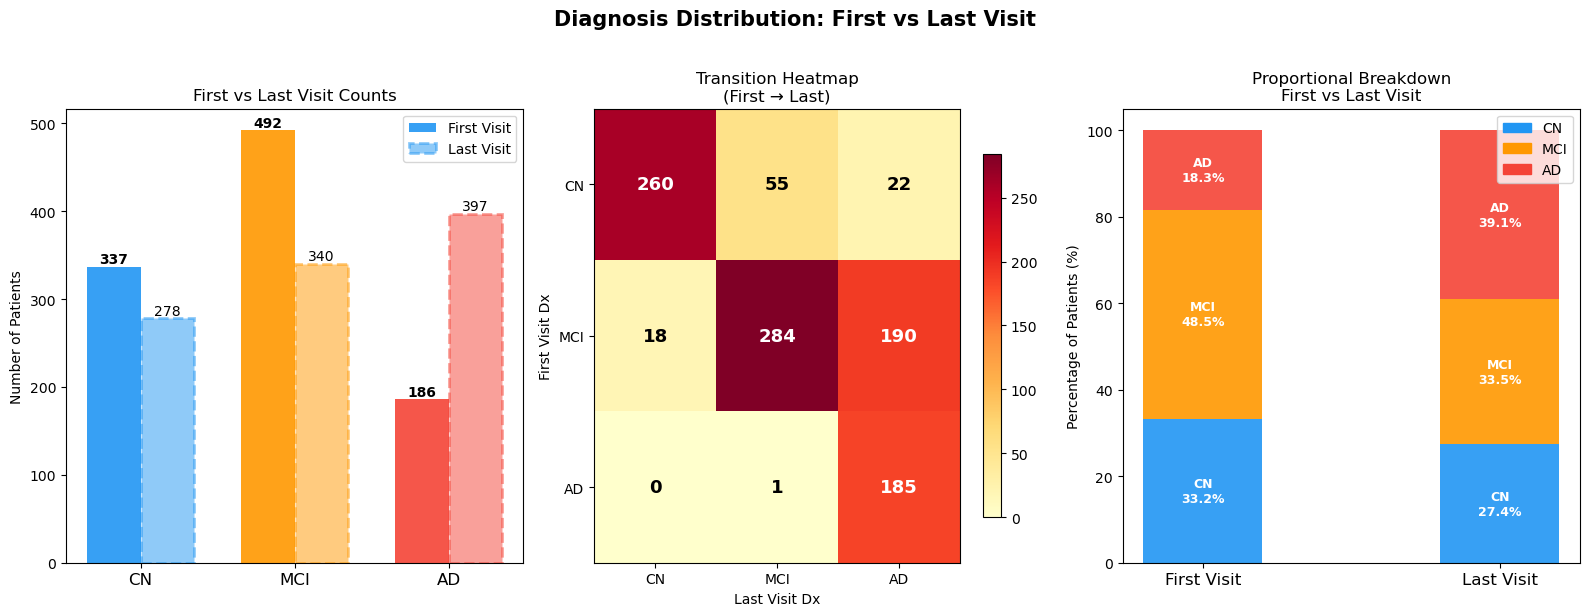

Plot saved.


In [455]:
# ── 1. Merge on RID + VISCODE ──────────────────────────────────────────────
merged = CSF_AD.merge(
    dx_df[['RID', 'VISCODE', 'DIAGNOSIS']],
    on=['RID', 'VISCODE'],
    how='left'
)

diag_map = {1: 'CN', 2: 'MCI', 3: 'AD'}
merged['DIAGNOSIS_LABEL'] = merged['DIAGNOSIS'].map(diag_map)

# ── 2. First & last visit per patient (by days_since_baseline}) ───────────────────
merged_sorted = merged.sort_values(['RID', 'days_since_entry'])

first_visit = merged_sorted.groupby('RID').first().reset_index()
last_visit  = merged_sorted.groupby('RID').last().reset_index()

first_counts = first_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)
last_counts  = last_visit['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'AD'], fill_value=0)

print("=== First Visit Diagnosis ===")
print(first_counts)
print(f"  Missing: {first_visit['DIAGNOSIS_LABEL'].isna().sum()}")

print("\n=== Last Visit Diagnosis ===")
print(last_counts)
print(f"  Missing: {last_visit['DIAGNOSIS_LABEL'].isna().sum()}")

# ── 3. Sankey-style transition counts ─────────────────────────────────────
transitions = merged_sorted.groupby('RID').agg(
    first_dx=('DIAGNOSIS_LABEL', 'first'),
    last_dx=('DIAGNOSIS_LABEL', 'last')
).reset_index()

transition_counts = transitions.groupby(['first_dx', 'last_dx']).size().reset_index(name='count')
print("\n=== Transition counts (first → last) ===")
print(transition_counts.pivot(index='first_dx', columns='last_dx', values='count').fillna(0))

# ── 4. Plot ────────────────────────────────────────────────────────────────
colors = {'CN': '#2196F3', 'MCI': '#FF9800', 'AD': '#F44336'}
categories = ['CN', 'MCI', 'AD']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Diagnosis Distribution: First vs Last Visit', fontsize=15, fontweight='bold', y=1.02)

# — Panel 1: Grouped bar chart —
ax1 = axes[0]
x = np.arange(len(categories))
w = 0.35
bars1 = ax1.bar(x - w/2, [first_counts[c] for c in categories], w,
                label='First Visit', color=[colors[c] for c in categories], alpha=0.9)
bars2 = ax1.bar(x + w/2, [last_counts[c] for c in categories],  w,
                label='Last Visit',  color=[colors[c] for c in categories], alpha=0.5,
                edgecolor=[colors[c] for c in categories], linewidth=2, linestyle='--')
ax1.set_xticks(x); ax1.set_xticklabels(categories, fontsize=12)
ax1.set_ylabel('Number of Patients'); ax1.set_title('First vs Last Visit Counts')
ax1.legend()
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# — Panel 2: Transition heatmap —
ax2 = axes[1]
pivot = transitions.groupby(['first_dx', 'last_dx']).size().unstack(fill_value=0).reindex(
    index=categories, columns=categories, fill_value=0)
im = ax2.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(len(categories))); ax2.set_xticklabels(categories)
ax2.set_yticks(range(len(categories))); ax2.set_yticklabels(categories)
ax2.set_xlabel('Last Visit Dx'); ax2.set_ylabel('First Visit Dx')
ax2.set_title('Transition Heatmap\n(First → Last)')
for i in range(len(categories)):
    for j in range(len(categories)):
        val = pivot.values[i, j]
        ax2.text(j, i, str(int(val)), ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if val > pivot.values.max()*0.6 else 'black')
plt.colorbar(im, ax=ax2, shrink=0.8)

# — Panel 3: Stacked % bar —
ax3 = axes[2]
total_first = first_counts.sum()
total_last  = last_counts.sum()
bottom_f = bottom_l = 0
for cat in categories:
    pf = first_counts[cat] / total_first * 100
    pl = last_counts[cat]  / total_last  * 100
    ax3.bar(0, pf, bottom=bottom_f, color=colors[cat], alpha=0.9, width=0.4)
    ax3.bar(1, pl, bottom=bottom_l, color=colors[cat], alpha=0.9, width=0.4)
    if pf > 3: ax3.text(0, bottom_f + pf/2, f'{cat}\n{pf:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    if pl > 3: ax3.text(1, bottom_l + pl/2, f'{cat}\n{pl:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom_f += pf; bottom_l += pl
ax3.set_xticks([0, 1]); ax3.set_xticklabels(['First Visit', 'Last Visit'], fontsize=12)
ax3.set_ylabel('Percentage of Patients (%)'); ax3.set_title('Proportional Breakdown\nFirst vs Last Visit')
patches = [mpatches.Patch(color=colors[c], label=c) for c in categories]
ax3.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.savefig('diagnosis_first_last.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [456]:
# ── Group 1: All patients ──────────────────────────────────────────────────
df_all = CSF_AD.merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 1 - All patients:          n = {df_all['RID'].nunique()} patients, {len(df_all)} rows")

# ── Group 2: End up as MCI or AD at last visit ─────────────────────────────
progressors_rid = transitions[transitions['last_dx'].isin(['MCI', 'AD'])]['RID']
df_progressors = CSF_AD[CSF_AD['RID'].isin(progressors_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 2 - End MCI or AD:         n = {df_progressors['RID'].nunique()} patients, {len(df_progressors)} rows")

# ── Group 3: End up as AD at last visit ────────────────────────────────────
ad_converters_rid = transitions[transitions['last_dx'] == 'AD']['RID']
df_ad_converters = CSF_AD[CSF_AD['RID'].isin(ad_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 3 - End AD:                n = {df_ad_converters['RID'].nunique()} patients, {len(df_ad_converters)} rows")

# ── Group 4: AD at entry (first visit already AD) ─────────────────────────
ad_at_entry_rid = transitions[transitions['first_dx'] == 'AD']['RID']
df_ad_entry = CSF_AD[CSF_AD['RID'].isin(ad_at_entry_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 4 - AD at entry:           n = {df_ad_entry['RID'].nunique()} patients, {len(df_ad_entry)} rows")

# ── Group 5: MCI converters — start CN or MCI, end as AD ──────────────────
mci_converters_rid = transitions[
    (transitions['last_dx'] == 'AD') &
    (transitions['first_dx'].isin(['CN', 'MCI']))
]['RID']
df_mci_converters = CSF_AD[CSF_AD['RID'].isin(mci_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 5 - MCI converters:        n = {df_mci_converters['RID'].nunique()} patients, {len(df_mci_converters)} rows")

# ── Summary table ──────────────────────────────────────────────────────────
print("\n=== First → Last diagnosis breakdown per group ===")
for name, df in [("All", df_all), ("End MCI/AD", df_progressors),
                 ("End AD", df_ad_converters), ("AD at entry", df_ad_entry),
                  ("MCI converters", df_mci_converters)]:
    print(f"\n{name}:")
    print(df.drop_duplicates('RID')[['first_dx', 'last_dx']]
            .groupby(['first_dx', 'last_dx']).size().reset_index(name='n').to_string(index=False))

Group 1 - All patients:          n = 1015 patients, 5856 rows
Group 2 - End MCI or AD:         n = 737 patients, 4145 rows
Group 3 - End AD:                n = 397 patients, 2059 rows
Group 4 - AD at entry:           n = 186 patients, 606 rows
Group 5 - MCI converters:        n = 212 patients, 1457 rows

=== First → Last diagnosis breakdown per group ===

All:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1
      CN      AD  22
      CN      CN 260
      CN     MCI  55
     MCI      AD 190
     MCI      CN  18
     MCI     MCI 284

End MCI/AD:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1
      CN      AD  22
      CN     MCI  55
     MCI      AD 190
     MCI     MCI 284

End AD:
first_dx last_dx   n
      AD      AD 185
      CN      AD  22
     MCI      AD 190

AD at entry:
first_dx last_dx   n
      AD      AD 185
      AD     MCI   1

MCI converters:
first_dx last_dx   n
      CN      AD  22
     MCI      AD 190


In [457]:
# Last visit per patient
last_visit_ad = (
    df_ad_converters
    .sort_values(['RID', 'days_since_entry'])
    .groupby('RID')
    .last()
    .reset_index()
)

# Convert to years
last_visit_ad['years_since_entry'] = last_visit_ad['days_since_entry'] / 365.25

# Average follow-up time
avg_years = last_visit_ad['years_since_entry'].mean()

print(f"Average time from baseline to last visit (AD converters): {avg_years:.2f} years")

Average time from baseline to last visit (AD converters): 3.41 years


In [458]:
# Check proportion of inidividuals with comorbidities of interest

for df, name in [(CSF_AD, "All patients"), (df_progressors, "Progressors"), (df_ad_converters, "End with AD"), (df_mci_converters, "Convert to AD")]:
    print(f"\n=== {name} (n={df['RID'].nunique()}) ===")
    for condition in ["UTI", "Sleep", "CM"]:
        n = df[df[condition] == 1]["RID"].nunique()
        print(f"  {condition}: {n} patients ({100*n/df['RID'].nunique():.1f}%)")


=== All patients (n=1015) ===
  UTI: 114 patients (11.2%)
  Sleep: 183 patients (18.0%)
  CM: 69 patients (6.8%)

=== Progressors (n=737) ===
  UTI: 90 patients (12.2%)
  Sleep: 149 patients (20.2%)
  CM: 50 patients (6.8%)

=== End with AD (n=397) ===
  UTI: 49 patients (12.3%)
  Sleep: 73 patients (18.4%)
  CM: 21 patients (5.3%)

=== Convert to AD (n=212) ===
  UTI: 27 patients (12.7%)
  Sleep: 41 patients (19.3%)
  CM: 9 patients (4.2%)


### MLM prediction of ADAS-Cog13 total score:

In [ ]:
print(compare_lin_quad("TOTAL13", df_ad_converters, "converters"))


Significant predictors for TOTAL13:
                            coef           pval
Intercept              12.598328  1.198548e-111
time_years              2.105381   3.990578e-04
age_c                   0.123005   4.709459e-05
edu_c                  -0.117491   4.610463e-02
baseline_c              1.021637   0.000000e+00
time_years:baseline_c   0.080032   2.069930e-04
time_years:PT_AB_std    0.750624   4.810600e-05
time_years:age_c       -0.108181   1.037500e-03
time_years:Sleep       -1.128819   1.012367e-02
time_years:UTI          1.880840   2.379042e-04
RID Var                 0.162826   4.973958e-05
RID x time_years Cov    0.134138   1.821513e-06
time_years Var          0.402500   5.193057e-12


/var/folders/g_/qzn_bmsd7v9fwp049f83fwtr0000gp/T/ipykernel_31453/3294640164.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])



Saved files:
 → linear_converters_TOTAL13_trajectories.png
 → linear_converters_TOTAL13_significant_results.csv

Significant predictors for TOTAL13:
                            coef  CI_lower  CI_upper    pval
Intercept                14.3508   13.3341   15.3675  0.0000
time_sq                   0.2642    0.2222    0.3062  0.0000
time_sq:CARRIER[T.True]  -0.0624   -0.1122   -0.0126  0.0140
baseline_c                0.9681    0.9335    1.0026  0.0000
time_years:baseline_c     0.1135    0.0639    0.1632  0.0000
time_sq:baseline_c        0.0053    0.0016    0.0091  0.0053
time_years:PT_AB_std      0.7691    0.3383    1.1999  0.0005
time_years:PTGENDER       0.8159    0.0087    1.6232  0.0476
time_sq:edu_c             0.0245    0.0145    0.0346  0.0000
time_sq:age_c            -0.0168   -0.0229   -0.0107  0.0000
time_years:UTI            1.9149    0.7107    3.1192  0.0018
time_sq:Sleep            -0.1186   -0.1824   -0.0547  0.0003
time_sq:CM               -0.1184   -0.2331   -0.0037  0.0

In [ ]:
# Define the features to compare between UTI and non-UTI individuals
features = [
    'TOTAL13_AD_start',  # baseline score
    'PTAU_ABETA42',      # ptau/abeta ratio
    'age_c',             # or raw age if you have it
    'edu_c',             # or raw education
    'PTGENDER',
    'CARRIER',           # APOE
    # add any other baseline covariates
]

# Split into UTI and non-UTI groups
uti_group = df_ad_converters[df_ad_converters['UTI'] == 1]
non_uti_group = df_ad_converters[df_ad_converters['UTI'] == 0]
full_cohort = df_ad_converters  

# Compare means
comparison = pd.DataFrame({
    f'UTI (n={(uti_group["RID"].nunique())}))': uti_group[features].mean(),
    f'Non-UTI (n={(non_uti_group["RID"].nunique())}))': non_uti_group[features].mean(),
    f'Full cohort (n={(full_cohort["RID"].nunique())}))': full_cohort[features].mean()
})

print(comparison.round(3))

                  UTI (n=49))  Non-UTI (n=348))  Full cohort (n=397))
TOTAL13_AD_start       20.260            21.586                21.407
PTAU_ABETA42            0.049             0.056                 0.055
age_c                   2.095             0.725                 0.910
edu_c                  -1.534            -0.183                -0.365
PTGENDER                1.572             1.375                 1.401
CARRIER                 0.597             0.629                 0.625


In [ ]:
# Compare results of the 2 cohorts that make up ad_converters
print(compare_lin_quad("TOTAL13", df_mci_converters, "non-ad-converters"))
print(compare_lin_quad("TOTAL13", df_ad_entry, "ad-starters"))



Significant predictors for TOTAL13:
                           coef           pval
Intercept             12.539540   1.517474e-60
time_years             2.214348   4.922723e-04
age_c                  0.183526   2.933510e-05
baseline_c             0.967652  2.070568e-200
time_years:PT_AB_std   0.629107   1.386210e-03
time_years:age_c      -0.078045   3.534789e-02
time_years:Sleep      -1.382936   3.020537e-03
time_years:UTI         1.430027   1.014409e-02
RID Var                0.202194   2.359556e-04
RID x time_years Cov   0.094242   2.645668e-03
time_years Var         0.288346   4.799578e-10

Saved files:
 → linear_non-ad-converters_TOTAL13_trajectories.png
 → linear_non-ad-converters_TOTAL13_significant_results.csv

Significant predictors for TOTAL13:
                            coef  CI_lower  CI_upper    pval
Intercept                14.4259   13.0410   15.8108  0.0000
time_sq                   0.2578    0.2126    0.3030  0.0000
time_sq:CARRIER[T.True]  -0.0631   -0.1170   -0.0092

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti


Significant predictors for TOTAL13:
                            coef           pval
Intercept              14.958355   9.689064e-83
baseline_c              0.949368  6.831809e-268
time_years:baseline_c   0.180010   3.577162e-03
time_years:PT_AB_std    0.937305   4.695415e-02
time_years:UTI          2.768821   3.320058e-02

Saved files:
 → linear_ad-starters_TOTAL13_trajectories.png
 → linear_ad-starters_TOTAL13_significant_results.csv


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood opti


Significant predictors for TOTAL13:
                       coef  CI_lower  CI_upper    pval
Intercept           14.7683   13.2396   16.2969  0.0000
baseline_c           0.9918    0.9343    1.0494  0.0000
time_sq:baseline_c   0.1335    0.0579    0.2092  0.0005
time_sq:age_c       -0.1108   -0.1923   -0.0292  0.0078

Model fit statistics:
  N patients:       186
  N observations:   606
  BIC:              3621.02
  Marginal R²:      0.896
  Conditional R²:   0.897
  Random intercept variance: 0.052
  Residual variance:         9.168

Saved files:
 → quadratic_ad-starters_TOTAL13_trajectories.png
 → quadratic_ad-starters_TOTAL13_significant_results.csv
BIC Linear: 3589.6167547525397
BIC Quadratic: 3621.0232472316393
None


### CDR

In [393]:
CDR = pd.read_csv("data/CDR_19Feb2026.csv")
df_CDR = df_ad_converters.merge(CDR[["RID", "VISCODE", "CDRSB"]], on=["RID", "VISCODE"], how="inner")
df_CDR.dropna(subset=["CDRSB"], inplace=True)
print(df_CDR["RID"].nunique())

386


In [406]:
print(compare_lin_quad("CDRSB", df_CDR, "end-ad"))


Significant predictors for CDRSB:
                           coef          pval
Intercept              1.050030  9.620867e-04
time_years             0.590518  9.116874e-04
baseline_c             0.177517  3.609819e-62
time_years:baseline_c  0.039091  1.874537e-08
time_years:PT_AB_std   0.132683  1.908421e-02
time_years:PTGENDER    0.271700  1.302167e-02
time_years:Sleep      -0.306037  1.961456e-02
time_years:UTI         0.380380  1.352576e-02
RID Var                1.330910  3.432516e-13
RID x time_years Cov   0.245531  1.271159e-04
time_years Var         0.339763  2.215168e-09

Saved files:
 → linear_end-ad_CDRSB_trajectories.png
 → linear_end-ad_CDRSB_significant_results.csv

Significant predictors for CDRSB:
                           coef  CI_lower  CI_upper    pval
Intercept                1.6960    1.0711    2.3208  0.0000
time_sq                  0.0843    0.0699    0.0988  0.0000
time_sq:CARRIER[T.True] -0.0150   -0.0322    0.0023  0.0895
baseline_c               0.1449    0.

### MMSE

In [398]:
MMSE = pd.read_csv("data/MMSE_11Mar2026.csv")
print(MMSE.columns)
df_MMSE = df_ad_converters.merge(MMSE[["RID", "VISCODE", "MMSCORE"]], on=["RID", "VISCODE"], how="inner")
df_MMSE.dropna(subset=["MMSCORE"], inplace=True)
print(df_MMSE["RID"].nunique())

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'DONE',
       'NDREASON', 'SOURCE', 'MMDATE', 'MMYEAR', 'MMMONTH', 'MMDAY',
       'MMSEASON', 'MMHOSPIT', 'MMFLOOR', 'MMCITY', 'MMAREA', 'MMSTATE',
       'WORDLIST', 'WORD1', 'WORD2', 'WORD3', 'MMTRIALS', 'MMD', 'MML', 'MMR',
       'MMO', 'MMW', 'MMLTR1', 'MMLTR2', 'MMLTR3', 'MMLTR4', 'MMLTR5',
       'MMLTR6', 'MMLTR7', 'WORLDSCORE', 'WORD1DL', 'WORD2DL', 'WORD3DL',
       'MMWATCH', 'MMPENCIL', 'MMREPEAT', 'MMHAND', 'MMFOLD', 'MMONFLR',
       'MMREAD', 'MMWRITE', 'MMDRAW', 'MMSCORE', 'ID', 'SITEID', 'USERDATE',
       'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')
387


In [409]:
print(compare_lin_quad("MMSCORE", df_MMSE, "end-ad"))


Significant predictors for MMSCORE:
                            coef          pval
Intercept              27.966769  0.000000e+00
time_years             -0.926737  4.326604e-04
age_c                  -0.054801  2.596663e-02
edu_c                   0.183905  1.381995e-04
baseline_c             -0.274226  8.997361e-70
UTI                     1.213330  2.200699e-03
time_years:baseline_c  -0.074430  2.240595e-12
time_years:PT_AB_std   -0.315005  1.626450e-04
time_years:age_c        0.045879  2.329269e-03
time_years:edu_c       -0.091782  1.486465e-03
time_years:Sleep        0.853314  9.487069e-06
time_years:UTI         -0.673365  3.120544e-03
RID Var                 0.758231  2.244820e-08
time_years Var          0.216750  3.540590e-07

Saved files:
 → linear_end-ad_MMSCORE_trajectories.png
 → linear_end-ad_MMSCORE_significant_results.csv

Significant predictors for MMSCORE:
                            coef  CI_lower  CI_upper    pval
Intercept                27.1794   26.2297   28.1291  0

### FAQ

In [460]:
FAQ = pd.read_csv('data/FAQ_24Feb2026.csv')
FAQ = FAQ.dropna(subset=['FAQTOTAL'])
df_FAQ = df_ad_converters.merge(FAQ[["RID", "VISCODE", "FAQTOTAL"]], on=["RID", "VISCODE"], how="inner")
print(df_FAQ["RID"].nunique())


396


In [462]:
# ── 1. Distribution diagnostics ───────────────────────────────────────────
MAX_FAQ = 30
eps = 0.5

floor_pct = 100*(df_FAQ['FAQTOTAL'] == 0).mean()
ceiling_pct = 100*(df_FAQ['FAQTOTAL'] == 30).mean()
near_floor_pct = 100*(df_FAQ['FAQTOTAL'] <= 2).mean()
near_ceiling_pct = 100*(df_FAQ['FAQTOTAL'] >= 28).mean()

print("=== FAQ Score Distribution (df_ad_converters) ===")
print(f"N patients: {df_FAQ['RID'].nunique()}")
print(f"N rows:     {len(df_FAQ)}")
print(df_FAQ['FAQTOTAL'].describe())
print(f"\nAt floor  (=0):    {floor_pct:.1f}% of visits")
print(f"At ceiling (=30):  {ceiling_pct:.1f}% of visits")
print(f"Near floor (≤2):   {near_floor_pct:.1f}% of visits")
print(f"Near ceiling (≥28):{near_ceiling_pct:.1f}% of visits")

# ── 2. Apply logit transform ───────────────────────────────────────────────
df_FAQ = df_FAQ.copy()
df_FAQ['FAQ_clipped'] = df_FAQ['FAQTOTAL'].clip(eps, MAX_FAQ - eps)
df_FAQ['FAQ_logit'] = np.log(
    df_FAQ['FAQ_clipped'] / (MAX_FAQ - df_FAQ['FAQ_clipped'])
)

# ── 3. Run logit model ─────────────────────────────────────────────────────
formula_faq_logit = """
    FAQ_logit ~ time_years + time_sq
    + CARRIER + age_c + PTGENDER + edu_c + PT_AB_std + baseline_c
    + Sleep + UTI + CM
    + time_years:baseline_c
    + time_sq:baseline_c
    + time_years:CARRIER
    + time_sq:CARRIER
    + time_years:PT_AB_std
    + time_sq:PT_AB_std
    + time_years:age_c
    + time_sq:age_c
    + time_years:edu_c
    + time_sq:edu_c
    + time_years:UTI
    + time_sq:UTI
    + time_years:CM
    + time_sq:CM
    + time_years:Sleep
    + time_sq:Sleep
    """

model_logit = smf.mixedlm(
    formula_faq_logit,
    data=df_FAQ,
    groups='RID',
    re_formula='~time_years'
).fit(reml=False)

results_logit = pd.DataFrame({
    'coef': model_logit.fe_params,
    'pval': model_logit.pvalues
})
sig_logit = results_logit[results_logit['pval'] < 0.1].round(6)
print("\n=== Significant predictors (logit FAQ, df_ad_converters) ===")
print(sig_logit)
print(f"\nBIC logit model: {model_logit.bic:.2f}")

# ── Extract confidence intervals from logit model ──────────────────────────
conf_int_logit = model_logit.conf_int()  # Default 95% CI
conf_int_logit.columns = ['CI_lower', 'CI_upper']

# Combine with coefficients
results_logit_ci = pd.DataFrame({
    'coef': model_logit.fe_params,
    'CI_lower': conf_int_logit['CI_lower'],
    'CI_upper': conf_int_logit['CI_upper'],
    'pval': model_logit.pvalues
})

# Filter for significant predictors
sig_logit_ci = results_logit_ci[results_logit_ci['pval'] < 0.1]

print("\n=== Significant predictors with 95% CI (logit scale) ===")
print(sig_logit_ci.round(6))

# ── Back-transform to FAQ units at mean FAQ ────────────────────────────────
mean_logit = df_FAQ['FAQ_logit'].mean()
mean_faq = logit_to_faq(mean_logit)
p = np.exp(mean_logit) / (1 + np.exp(mean_logit))

# Derivative: d(FAQ)/d(logit) = MAX_FAQ * p * (1-p)
derivative = MAX_FAQ * p * (1 - p)

print(f"\n=== Effect sizes in FAQ points (evaluated at mean FAQ={mean_faq:.1f}) ===")
print(f"{'Term':<35} {'Logit Coef':>12} {'95% CI (logit)':>25} {'FAQ Δ':>10} {'95% CI (FAQ)':>20}")
print("-" * 105)

for term in sig_logit_ci.index:
    if 'time' in term:  # Focus on time-related effects
        coef = sig_logit_ci.loc[term, 'coef']
        ci_low = sig_logit_ci.loc[term, 'CI_lower']
        ci_up = sig_logit_ci.loc[term, 'CI_upper']
        
        # Convert to FAQ units
        faq_coef = coef * derivative
        faq_ci_low = ci_low * derivative
        faq_ci_up = ci_up * derivative
        
        print(f"{term:<35} {coef:>12.4f} "
              f"[{ci_low:>7.4f}, {ci_up:>7.4f}] "
              f"{faq_coef:>10.3f} "
              f"[{faq_ci_low:>6.3f}, {faq_ci_up:>6.3f}]")

=== FAQ Score Distribution (df_ad_converters) ===
N patients: 396
N rows:     2051
count    2051.000000
mean       11.247684
std         8.565449
min        -1.000000
25%         4.000000
50%        10.000000
75%        18.000000
max        30.000000
Name: FAQTOTAL, dtype: float64

At floor  (=0):    9.5% of visits
At ceiling (=30):  1.1% of visits
Near floor (≤2):   20.2% of visits
Near ceiling (≥28):3.5% of visits

=== Significant predictors (logit FAQ, df_ad_converters) ===
                           coef      pval
CM                    -0.499249  0.091767
Intercept             -2.317413  0.000000
RID Var                     NaN  0.000000
baseline_c             0.110111  0.000000
edu_c                  0.050594  0.031200
time_sq                0.024772  0.000000
time_sq:CM            -0.020440  0.092940
time_sq:UTI           -0.015697  0.025359
time_sq:age_c         -0.001610  0.013525
time_sq:baseline_c    -0.002097  0.000000
time_sq:edu_c          0.002093  0.050341
time_years    

### ADAS subdomain analysis:

In [327]:
wl1_correct = ['ADAS_Q8_WL1_REC_W2_magazine', 'ADAS_Q8_WL1_REC_W3_wizard', 'ADAS_Q8_WL1_REC_W4_van',
               'ADAS_Q8_WL1_REC_W5_leopard', 'ADAS_Q8_WL1_REC_W7_sea', 'ADAS_Q8_WL1_REC_W8_train', 
               'ADAS_Q8_WL1_REC_W9_coin', 'ADAS_Q8_WL1_REC_W11_institution', 'ADAS_Q8_WL1_REC_W14_board',
               'ADAS_Q8_WL1_REC_W19_anchor', 'ADAS_Q8_WL1_REC_W20_gem', 'ADAS_Q8_WL1_REC_W22_fund',]

wl1_incorrect = ['ADAS_Q8_WL1_REC_W1_nurse', 'ADAS_Q8_WL1_REC_W6_sale', 'ADAS_Q8_WL1_REC_W10_ship',
                 'ADAS_Q8_WL1_REC_W12_map', 'ADAS_Q8_WL1_REC_W13_axe','ADAS_Q8_WL1_REC_W15_carrot', 
                 'ADAS_Q8_WL1_REC_W16_milk', 'ADAS_Q8_WL1_REC_W17_volume', 'ADAS_Q8_WL1_REC_W18_forest',
                 'ADAS_Q8_WL1_REC_W21_cat', 'ADAS_Q8_WL1_REC_W23_edge', 'ADAS_Q8_WL1_REC_W24_cake']

wl2_correct = ['ADAS_Q8_WL2_REC_W1_cost', 'ADAS_Q8_WL2_REC_W3_chimney', 'ADAS_Q8_WL2_REC_W5_damages',
               'ADAS_Q8_WL2_REC_W7_sandwich',  'ADAS_Q8_WL2_REC_W10_solution', 'ADAS_Q8_WL2_REC_W12_tube',
               'ADAS_Q8_WL2_REC_W16_engine', 'ADAS_Q8_WL2_REC_W17_riches', 'ADAS_Q8_WL2_REC_W18_gravity',
               'ADAS_Q8_WL2_REC_W22_meal', 'ADAS_Q8_WL2_REC_W23_passenger', 'ADAS_Q8_WL2_REC_W24_acid']

wl2_incorrect = ['ADAS_Q8_WL2_REC_W2_nation', 'ADAS_Q8_WL2_REC_W4_sparrow', 'ADAS_Q8_WL2_REC_W6_traffic', 
                 'ADAS_Q8_WL2_REC_W8_service', 'ADAS_Q8_WL2_REC_W9_shell', 'ADAS_Q8_WL2_REC_W11_yard', 
                 'ADAS_Q8_WL2_REC_W13_body', 'ADAS_Q8_WL2_REC_W14_ground', 'ADAS_Q8_WL2_REC_W15_stick', 
                 'ADAS_Q8_WL2_REC_W19_summer', 'ADAS_Q8_WL2_REC_W20_wisdom', 'ADAS_Q8_WL2_REC_W21_man',]

wl3_correct = ['ADAS_Q8_WL3_REC_W1_silence', 'ADAS_Q8_WL3_REC_W3_daughter', 'ADAS_Q8_WL3_REC_W6_forehead',
               'ADAS_Q8_WL3_REC_W7_tiger', 'ADAS_Q8_WL3_REC_W8_twilight', 'ADAS_Q8_WL3_REC_W12_beggar',
               'ADAS_Q8_WL3_REC_W13_echo', 'ADAS_Q8_WL3_REC_W16_village', 'ADAS_Q8_WL3_REC_W17_corner',
               'ADAS_Q8_WL3_REC_W20_courage', 'ADAS_Q8_WL3_REC_W21_bushel', 'ADAS_Q8_WL3_REC_W23_object']

wl3_incorrect = ['ADAS_Q8_WL3_REC_W2_elbow', 'ADAS_Q8_WL3_REC_W4_powder', 'ADAS_Q8_WL3_REC_W5_canal',
                 'ADAS_Q8_WL3_REC_W9_dragon', 'ADAS_Q8_WL3_REC_W10_chamber', 'ADAS_Q8_WL3_REC_W11_sister',
                 'ADAS_Q8_WL3_REC_W14_nephew', 'ADAS_Q8_WL3_REC_W15_duty', 'ADAS_Q8_WL3_REC_W18_olive',
                 'ADAS_Q8_WL3_REC_W19_music', 'ADAS_Q8_WL3_REC_W22_ribbon', 'ADAS_Q8_WL3_REC_W24_collar']

In [328]:
#adas = pd.read_csv('../Data/Raw/ADNI_ADAS_29Sep2025.csv')
adas = pd.read_csv('data/ITEM.csv')
print(adas.columns)
adas_cols = [col for col in adas.columns if col.startswith('ADAS_')]
adas = adas[adas_cols+['RID']]
adas = adas.drop(columns=['ADAS_Q1_TimeEnded', 'ADAS_QuestionnaireNotAttempted'])

## WORD RECALL ##
wls = ['WL1','WL2','WL3']
wr_titles = ['word_recall_1', 'word_recall_2', 'word_recall_3']
dr_titles = ['delayed_recall_1', 'delayed_recall_2', 'delayed_recall_3']

for i, wl in enumerate(wls):
    cols_to_sum = [col for col in adas.columns if col.startswith('ADAS_Q1_') and wl in col]
    sum_val = adas[cols_to_sum].sum(axis=1, skipna=False)
    adas[wr_titles[i]] = (30-sum_val)/3

adas['adas_word_recall'] = adas[wr_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan, 
    axis=1
)

## COMMANDS ##
commands_cols = [col for col in adas.columns if col.startswith('ADAS_Q2')]
adas['adas_commands'] = 5-(adas[commands_cols].sum(axis=1, skipna=False))

## CONSTRACTIONAL PRAXIS ##
cp_cols = [col for col in adas.columns if col.startswith('ADAS_Q3')]
adas['adas_constructional_praxis'] = 4-adas[cp_cols].sum(axis=1, skipna=False)

## DELAYED RECALL ##
for i, wl in enumerate(wls):
    cols_to_sum = [col for col in adas.columns if col.startswith('ADAS_Q4_') and wl in col]
    sum_val = adas[cols_to_sum].sum(axis=1, skipna=False)
    adas[dr_titles[i]] = 10-sum_val

adas['adas_delayed_recall'] = adas[dr_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan, 
    axis=1
)

## NAMING ##
naming_cols = [col for col in adas.columns if col.startswith('ADAS_Q5')]
adas['naming_correct'] = adas[naming_cols].sum(axis=1, skipna=False)

bins = [-1, 2, 5, 8, 11, 14, 17]
scores = [5, 4, 3, 2, 1, 0]

adas['adas_naming'] = pd.cut(adas['naming_correct'], bins=bins, labels=scores)
adas.drop(columns='naming_correct', inplace=True)

## IDEATIONAL PRAXIS ##
ip_cols = [col for col in adas.columns if col.startswith('ADAS_Q6')]
adas['adas_ideational_praxis'] = 5-adas[ip_cols].sum(axis=1, skipna=False)

## ORIENTATION ##
o_cols = [col for col in adas.columns if col.startswith('ADAS_Q7')]
adas['adas_orientation'] = 8-adas[o_cols].sum(axis=1, skipna=False)

## WORD RECOGNITION ##
correct = [wl1_correct, wl2_correct, wl3_correct]
incorrect = [wl1_incorrect, wl2_incorrect, wl3_incorrect]
wrec_titles = ['wrec_1', 'wrec_2', 'wrec_3']

for i, wl in enumerate(wls):
    correct_cols = correct[i]
    incorrect_cols = incorrect[i]
    sum_correct = 12-adas[correct_cols].sum(axis=1, skipna=False)
    sum_incorrect = adas[incorrect_cols].sum(axis=1, skipna=False)
    adas[wrec_titles[i]] = (sum_correct + sum_incorrect).clip(upper=12)

adas['adas_word_recognition'] = adas[wrec_titles].apply(
    lambda row: row.dropna().iloc[0] if row.notna().any() else np.nan,
    axis=1
)

## REMEMBERING INSTRUCTIONS, COMPREHENSIONS LANGUAGE, WORD FINDING, SPOKEN LANGUAGE ##
adas['adas_remembering_instructions'] = adas['ADAS_Q9']-1
adas['adas_comprehension_language'] = adas['ADAS_Q10']-1
adas['adas_word_finding'] = adas['ADAS_Q11']-1
adas['adas_spoken_language'] = adas['ADAS_Q12']-1

## NUMBER CANCELLATION ##
# num correctly crossed out - num errors - num of reminders
adas['adas_nc_premap'] = adas['ADAS_Q13a']-adas['ADAS_Q13b']-adas['ADAS_Q13c']
nc_bins = [-1, 4, 8, 12, 17, 22, 45]
nc_scores = [5,4,3,2,1,0]
adas['adas_number_cancellation'] = pd.cut(adas['adas_nc_premap'], bins=nc_bins, labels = nc_scores)

adas = adas[adas.columns.drop(list(adas.filter(regex='ADAS_Q1|word_recall_|ADAS_Q2|ADAS_Q3|ADAS_Q4|'
                                               'delayed_recall_|ADAS_Q5|ADAS_Q6|ADAS_Q7|_Reminder_|'
                                               'ADAS_Q9|ADAS_Q8|wrec|nc_premap')))]

adas['adas_total'] = round(adas[adas.drop(columns=['ADAS_ExamDate', 'RID']).columns].sum(axis=1, skipna=False), 2)
print(adas.columns)

Index(['RID', 'VISCODE', 'ADAS_QuestionnaireNotAttempted',
       'ADAS_Q1_T1_WL1_W1_butter', 'ADAS_Q1_T1_WL1_W2_arm',
       'ADAS_Q1_T1_WL1_W3_shore', 'ADAS_Q1_T1_WL1_W4_letter',
       'ADAS_Q1_T1_WL1_W5_queen', 'ADAS_Q1_T1_WL1_W6_cabin',
       'ADAS_Q1_T1_WL1_W7_pole',
       ...
       'TMT_PtA_Comission', 'TMT_PtA_Omission', 'TMT_PtB_Complete',
       'TMT_PtB_Comission', 'TMT_PtB_Omission', 'TMT_ExamDate',
       'WAISR_QuestionnaireNotAttempted', 'WAISR_Score', 'WAISR_ExamDate',
       'update_stamp'],
      dtype='object', length=766)
Index(['ADAS_ExamDate', 'RID', 'adas_word_recall', 'adas_commands',
       'adas_constructional_praxis', 'adas_delayed_recall', 'adas_naming',
       'adas_ideational_praxis', 'adas_orientation', 'adas_word_recognition',
       'adas_remembering_instructions', 'adas_comprehension_language',
       'adas_word_finding', 'adas_spoken_language', 'adas_number_cancellation',
       'adas_total'],
      dtype='object')


In [329]:
adas = adas.dropna()
adas['adas_number_cancellation'] = adas['adas_number_cancellation'].astype(int)
adas['adas_naming'] = adas['adas_naming'].astype(int)
adas.describe()

,RID,adas_word_recall,adas_commands,adas_constructional_praxis,adas_delayed_recall,adas_naming,adas_ideational_praxis,adas_orientation,adas_word_recognition,adas_remembering_instructions,adas_comprehension_language,adas_word_finding,adas_spoken_language,adas_number_cancellation,adas_total
count,3108.000000,3108.000000,3108.000000,3108.000000,3108.00000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000,3108.000000
mean,676.521557,4.557057,0.222008,0.556306,5.93565,0.286036,0.197233,1.080116,4.515122,0.156049,0.173745,0.379665,0.160875,1.072394,19.292317
std,409.772482,1.906290,0.561853,0.632544,3.04505,0.614887,0.554148,1.604132,3.296343,0.660952,0.538262,0.769551,0.532667,1.187684,11.225167
min,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,313.500000,3.333333,0.000000,0.000000,3.00000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.330000
50%,668.500000,4.666667,0.000000,0.000000,6.00000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,17.670000
75%,1028.000000,5.666667,0.000000,1.000000,9.00000,0.000000,0.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,2.000000,26.000000
max,1435.000000,10.000000,5.000000,4.000000,10.00000,5.000000,5.000000,8.000000,12.000000,5.000000,5.000000,5.000000,4.000000,5.000000,71.000000


In [330]:
print(CSF_AD["VISDATE"].head())

0    2008-05-12
1    2007-05-24
2    2008-12-01
3    2008-05-29
4    2007-11-15
Name: VISDATE, dtype: object


In [331]:
adas.rename(columns={'ADAS_ExamDate':'VISDATE'}, inplace=True)

adas['VISDATE'] = pd.to_datetime(adas['VISDATE'], dayfirst=True)#.dt.date
CSF_AD['VISDATE'] = pd.to_datetime(CSF_AD['VISDATE'])

subscores_df = adas.merge(CSF_AD, on=["RID", "VISDATE"], how="inner")

print(subscores_df.columns)
print(subscores_df["RID"].nunique())

Index(['VISDATE', 'RID', 'adas_word_recall', 'adas_commands',
       'adas_constructional_praxis', 'adas_delayed_recall', 'adas_naming',
       'adas_ideational_praxis', 'adas_orientation', 'adas_word_recognition',
       'adas_remembering_instructions', 'adas_comprehension_language',
       'adas_word_finding', 'adas_spoken_language', 'adas_number_cancellation',
       'adas_total', 'TOTAL13', 'TOTAL13_AD_start', 'VISCODE', 'PHASE',
       'days_since_entry', 'age_at_baseline', 'PTGENDER', 'CARRIER', 'HOMO',
       'PTEDUCAT', 'CNS', 'total_conditions', 'Peripheral', 'UTI', 'Sleep',
       'CM', 'age_c', 'edu_c', 'time_years', 'VISCODE2', 'ABETA42', 'TAU',
       'PTAU', 'PTAU_ABETA42', 'PT_AB_std', 'CSF_date', 'time_sq',
       'baseline_c'],
      dtype='object')
317


In [332]:
# --- ADAS-Cog subdomain groupings ---

# Memory (5 items)
memory_items = [
    'adas_word_recall',
    'adas_delayed_recall',
    'adas_word_recognition',
    'adas_orientation',
    'adas_remembering_instructions'
]

# Language (4 items)
language_items = [
    'adas_spoken_language',
    'adas_comprehension_language',
    'adas_word_finding',
    'adas_naming'
]

# Praxis + Commands (3 items)
# Commands placed here per Verma et al. (2015) empirical factor solution
praxis_items = [
    'adas_constructional_praxis',
    'adas_ideational_praxis',
    'adas_commands'
]

# Attention (1 item) — unique to ADAS-Cog 13, no established subdomain
attention_items = [
    'adas_number_cancellation'
]

# --- Create subdomain sum scores (NaN if ANY item missing) ---
subscores_df['adas_memory']    = subscores_df[memory_items].sum(axis=1, min_count=len(memory_items))
subscores_df['adas_language']  = subscores_df[language_items].sum(axis=1, min_count=len(language_items))
subscores_df['adas_praxis']    = subscores_df[praxis_items].sum(axis=1, min_count=len(praxis_items))
subscores_df['adas_attention'] = subscores_df[attention_items].sum(axis=1, min_count=len(attention_items))

# Check how many rows have any NaN subdomain
subdomain_cols = ['adas_memory', 'adas_language', 'adas_praxis', 'adas_attention']
n_incomplete = subscores_df[subdomain_cols].isna().any(axis=1).sum()
print(f"Rows with at least one incomplete subdomain: {n_incomplete}")

# Option A: leave as NaN (keep rows, analyses can handle missing subdomains)
# — subscores_df is already in this state

# Option B: drop rows where ANY subdomain is NaN
subscores_df_complete = subscores_df.dropna(subset=subdomain_cols)
print(f"Rows retained after dropping: {len(subscores_df_complete)} / {len(subscores_df)}")

# Sanity check: subdomain scores should sum to TOTAL13
subscores_df['adas_subdomain_total'] = (
    subscores_df[['adas_memory', 'adas_language', 'adas_praxis', 'adas_attention']].sum(axis=1)
)

# Quick verification
discrepancy = (subscores_df['adas_subdomain_total'] - subscores_df['TOTAL13']).abs()
print(f"Max discrepancy vs TOTAL13: {discrepancy.max()}")
print(f"Rows with discrepancy > 0: {(discrepancy > 0.01).sum()}")

Rows with at least one incomplete subdomain: 0
Rows retained after dropping: 1337 / 1337
Max discrepancy vs TOTAL13: 11.0
Rows with discrepancy > 0: 185


In [333]:
# ── Group 1: All patients ──────────────────────────────────────────────────
df_all = subscores_df.merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 1 - All patients:          n = {df_all['RID'].nunique()} patients, {len(df_all)} rows")

# ── Group 2: End up as MCI or AD at last visit ─────────────────────────────
progressors_rid = transitions[transitions['last_dx'].isin(['MCI', 'AD'])]['RID']
df_progressors = subscores_df[subscores_df['RID'].isin(progressors_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 2 - End MCI or AD:         n = {df_progressors['RID'].nunique()} patients, {len(df_progressors)} rows")

# ── Group 3: End up as AD at last visit ────────────────────────────────────
ad_converters_rid = transitions[transitions['last_dx'] == 'AD']['RID']
df_ad_converters = subscores_df[subscores_df['RID'].isin(ad_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 3 - End AD:                n = {df_ad_converters['RID'].nunique()} patients, {len(df_ad_converters)} rows")

# ── Group 4: AD at entry (first visit already AD) ─────────────────────────
ad_at_entry_rid = transitions[transitions['first_dx'] == 'AD']['RID']
df_ad_entry = subscores_df[subscores_df['RID'].isin(ad_at_entry_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 4 - AD at entry:           n = {df_ad_entry['RID'].nunique()} patients, {len(df_ad_entry)} rows")

# ── Group 5: MCI converters — start CN or MCI, end as AD ──────────────────
mci_converters_rid = transitions[
    (transitions['last_dx'] == 'AD') &
    (transitions['first_dx'].isin(['CN', 'MCI']))
]['RID']
df_mci_converters = subscores_df[subscores_df['RID'].isin(mci_converters_rid)].merge(
    transitions[['RID', 'first_dx', 'last_dx']],
    on='RID', how='left'
)
print(f"Group 5 - MCI converters:        n = {df_mci_converters['RID'].nunique()} patients, {len(df_mci_converters)} rows")

# ── Summary table ──────────────────────────────────────────────────────────
print("\n=== First → Last diagnosis breakdown per group ===")
for name, df in [("All", df_all), ("End MCI/AD", df_progressors),
                 ("End AD", df_ad_converters), ("AD at entry", df_ad_entry),
                  ("MCI converters", df_mci_converters)]:
    print(f"\n{name}:")
    print(df.drop_duplicates('RID')[['first_dx', 'last_dx']]
            .groupby(['first_dx', 'last_dx']).size().reset_index(name='n').to_string(index=False))

Group 1 - All patients:          n = 317 patients, 1337 rows
Group 2 - End MCI or AD:         n = 251 patients, 1052 rows
Group 3 - End AD:                n = 166 patients, 693 rows
Group 4 - AD at entry:           n = 73 patients, 244 rows
Group 5 - MCI converters:        n = 93 patients, 449 rows

=== First → Last diagnosis breakdown per group ===

All:
first_dx last_dx  n
      AD      AD 73
      CN      AD  9
      CN      CN 65
      CN     MCI 18
     MCI      AD 84
     MCI      CN  1
     MCI     MCI 67

End MCI/AD:
first_dx last_dx  n
      AD      AD 73
      CN      AD  9
      CN     MCI 18
     MCI      AD 84
     MCI     MCI 67

End AD:
first_dx last_dx  n
      AD      AD 73
      CN      AD  9
     MCI      AD 84

AD at entry:
first_dx last_dx  n
      AD      AD 73

MCI converters:
first_dx last_dx  n
      CN      AD  9
     MCI      AD 84


In [340]:
print(compare_lin_quad("adas_memory", df_ad_converters, "end_AD"))


Significant predictors for adas_memory:
                           coef           pval
Intercept             12.428323   6.661442e-64
baseline_c             0.728960  9.695907e-168
time_years:PT_AB_std   0.559422   1.379243e-02
RID x time_years Cov   0.185507   9.502152e-04
time_years Var         0.265326   1.858734e-03

Saved files:
 → linear_end_AD_adas_memory_trajectories.png
 → linear_end_AD_adas_memory_significant_results.csv

Significant predictors for adas_memory:
                         coef  CI_lower  CI_upper    pval
Intercept             12.3406   10.8085   13.8727  0.0000
baseline_c             0.7148    0.6561    0.7736  0.0000
time_years:UTI         2.4321    0.0669    4.7974  0.0439
time_sq:UTI           -1.0647   -1.9067   -0.2227  0.0132
RID Var                0.1924   -0.0080    0.3927  0.0598
RID x time_years Cov   0.2002    0.0870    0.3134  0.0005
time_years Var         0.2980    0.1145    0.4815  0.0015

Model fit statistics:
  N patients:       166
  N observat

In [341]:
print(compare_lin_quad("adas_language", df_ad_converters, "end_AD"))


Significant predictors for adas_language:
                           coef          pval
edu_c                  0.068099  1.500506e-02
baseline_c             0.086322  4.849919e-18
time_years:baseline_c  0.070874  4.208775e-08
time_years:UTI         0.676564  1.629562e-02
RID Var                0.253158  4.630151e-02
RID x time_years Cov   0.462410  2.220829e-07
time_years Var         0.844624  2.589247e-04

Saved files:
 → linear_end_AD_adas_language_trajectories.png
 → linear_end_AD_adas_language_significant_results.csv

Significant predictors for adas_language:
                         coef  CI_lower  CI_upper    pval
edu_c                  0.0756    0.0135    0.1377  0.0170
baseline_c             0.0882    0.0663    0.1102  0.0000
time_years:baseline_c  0.0602    0.0166    0.1039  0.0068
time_years:Sleep      -0.9656   -2.0656    0.1344  0.0853
time_years:UTI         0.8649   -0.0831    1.8129  0.0738
RID Var                0.2446   -0.0088    0.4979  0.0585
RID x time_years Cov   

In [342]:
print(compare_lin_quad("adas_praxis", df_ad_converters, "end_AD"))


Significant predictors for adas_praxis:
                           coef          pval
Intercept              0.672494  2.993151e-03
edu_c                 -0.053961  1.836986e-02
baseline_c             0.058999  3.125061e-13
time_years:baseline_c  0.020883  3.362605e-03
RID Var                0.472138  1.149765e-03
RID x time_years Cov   0.313098  1.305233e-05
time_years Var         0.296940  1.405110e-02

Saved files:
 → linear_end_AD_adas_praxis_trajectories.png
 → linear_end_AD_adas_praxis_significant_results.csv

Significant predictors for adas_praxis:
                         coef  CI_lower  CI_upper    pval
Intercept              0.7305    0.2648    1.1962  0.0021
edu_c                 -0.0756   -0.1253   -0.0258  0.0029
baseline_c             0.0567    0.0392    0.0743  0.0000
time_years:baseline_c  0.0251   -0.0043    0.0545  0.0948
time_years:PTGENDER    0.2324    0.0093    0.4555  0.0412
time_years:edu_c       0.0892    0.0146    0.1637  0.0191
time_sq:edu_c         -0.0279  

In [343]:
print(compare_lin_quad("adas_attention", df_ad_converters, "end_AD"))

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Significant predictors for adas_attention:
                          coef          pval
baseline_c            0.077177  6.543939e-22
RID Var               0.799517  2.918183e-05
RID x time_years Cov  0.348524  1.884563e-06
time_years Var        0.151928  4.146702e-02

Saved files:
 → linear_end_AD_adas_attention_trajectories.png
 → linear_end_AD_adas_attention_significant_results.csv

Significant predictors for adas_attention:
                        coef  CI_lower  CI_upper    pval
Intercept             0.4586    0.0029    0.9143  0.0486
CARRIER[T.True]      -0.2951   -0.6038    0.0135  0.0609
baseline_c            0.0807    0.0638    0.0977  0.0000
time_years:UTI        0.5601    0.0324    1.0878  0.0375
time_sq:UTI          -0.1627   -0.3503    0.0248  0.0890
time_sq:CM           -0.3115   -0.6324    0.0093  0.0570
RID Var               0.8143    0.4215    1.2071  0.0000
RID x time_years Cov  0.3666    0.2136    0.5197  0.0000
time_years Var        0.1651   -0.0002    0.3304  0.050

### Try removing 0 entries to eliminate floor effects causing odd quadratic behaviour

In [344]:
not_zero = df_ad_converters[df_ad_converters["adas_language"] > 0]
print(not_zero["RID"].nunique())

140


In [194]:
print(compare_lin_quad("adas_language", not_zero, "end_AD"))


Significant predictors for adas_language:
                           coef          pval
Intercept              1.216994  9.445912e-04
baseline_c             0.070394  6.377294e-05
time_years:baseline_c  0.063311  6.544347e-03
RID Var                4.062891  1.705367e-07
RID x time_years Cov  -1.879477  7.621348e-03
time_years Var         7.792507  1.634140e-08

Saved files:
 → linear_end_AD_adas_language_trajectories.png
 → linear_end_AD_adas_language_significant_results.csv

Significant predictors for adas_language:
                          coef          pval
Intercept             1.453071  9.710248e-05
baseline_c            0.073387  3.683959e-05
time_sq:baseline_c    0.015282  1.769916e-02
RID Var               4.315953  1.962447e-07
RID x time_years Cov -2.277463  4.204731e-03
time_years Var        9.208589  8.610897e-09

Saved files:
 → quadratic_end_AD_adas_language_trajectories.png
 → quadratic_end_AD_adas_language_significant_results.csv
BIC Linear: 2324.935488530897
BIC Qua

### Logitudinal PET results:

In [300]:
amyloid = pd.read_csv('data/UCBERKELEY_AMY_6MM_13Mar2026.csv')  
tau = pd.read_csv('data/UCBERKELEY_TAU_6MM_13Mar2026.csv')  
amyloid['VISCODE'].value_counts()
print(amyloid.columns  )

Index(['LONIUID', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'SCANDATE', 'SITEID',
       'PROCESSDATE', 'IMAGE_RESOLUTION', 'qc_flag',
       ...
       'RIGHT_PALLIDUM_VOLUME', 'RIGHT_PUTAMEN_SUVR', 'RIGHT_PUTAMEN_VOLUME',
       'RIGHT_THALAMUS_PROPER_SUVR', 'RIGHT_THALAMUS_PROPER_VOLUME',
       'RIGHT_VENTRALDC_SUVR', 'RIGHT_VENTRALDC_VOLUME', 'RIGHT_VESSEL_SUVR',
       'RIGHT_VESSEL_VOLUME', 'update_stamp'],
      dtype='object', length=344)


In [301]:
amyloid_converters = df_ad_converters.merge(
    amyloid[['RID', 'VISCODE', 'SUMMARY_SUVR']],
    left_on=['RID', 'VISCODE'],
    right_on=['RID', 'VISCODE'],    
    how='left')
amyloid_converters.rename(columns={'SUMMARY_SUVR': 'amyloid_SUVR'}, inplace=True)
amyloid_converters.dropna(subset=['amyloid_SUVR'], inplace=True)
print(f"ADAS-Cog converters with amyloid data: {amyloid_converters['RID'].nunique()} patients, {len(amyloid_converters)}  rows")

ADAS-Cog converters with amyloid data: 244 patients, 492  rows


In [303]:
print(amyloid_converters[['RID', 'VISCODE', 'amyloid_SUVR']].head())

      RID VISCODE  amyloid_SUVR
867   376     m48         0.888
868   292     m48         0.958
869   729     m48         1.446
870   626     m48         1.407
871  2047      bl         1.748


In [459]:
print(df_ad_converters.groupby(['RID','VISCODE']).size().sort_values(ascending=False).head())
print(amyloid.groupby(['RID','VISCODE']).size().sort_values(ascending=False).head())

RID   VISCODE
3     bl         1
4293  v03        1
4262  v03        1
4258  v21        1
      v11        1
dtype: int64
RID   VISCODE
5157  init       2
6830  bl         2
4278  y2         2
6757  bl         2
6643  y2         2
dtype: int64


In [305]:
tau_converters = df_ad_converters.merge(
    tau[['RID', 'VISCODE', 'META_TEMPORAL_SUVR']],
    left_on=['RID', 'VISCODE'],
    right_on=['RID', 'VISCODE'],    
    how='inner')
tau_converters.rename(columns={'META_TEMPORAL_SUVR': 'tau_SUVR'}, inplace=True)
print(f"ADAS-Cog converters with tau data: {tau_converters['RID'].nunique()} patients, {len(tau_converters)} rows")

ADAS-Cog converters with tau data: 43 patients, 84 rows


In [307]:
baseline_amyloid = (amyloid_converters[amyloid_converters['time_years'] == 0][['RID', 'amyloid_SUVR']].drop_duplicates(subset='RID')
)
amyloid_converters_new = amyloid_converters.merge(baseline_amyloid, on='RID', suffixes=('', '_baseline'))
print(amyloid_converters_new[['RID', 'amyloid_SUVR', 'amyloid_SUVR_baseline', 'time_years']].head(20))


     RID  amyloid_SUVR  amyloid_SUVR_baseline  time_years
0   2047         1.748                  1.748         0.0
1   2106         1.443                  1.443         0.0
2   2087         1.249                  1.249         0.0
3   2213         1.324                  1.324         0.0
4   2195         1.581                  1.581         0.0
5   2155         1.284                  1.284         0.0
6   2185         1.028                  1.028         0.0
7   2248         1.609                  1.609         0.0
8   2220         0.925                  0.925         0.0
9   2216         1.323                  1.323         0.0
10  2316         1.515                  1.515         0.0
11  2373         1.261                  1.261         0.0
12  2381         1.356                  1.356         0.0
13  2391         1.739                  1.739         0.0
14  2398         1.110                  1.110         0.0
15  2380         1.345                  1.345         0.0
16  2403      